<a href="https://colab.research.google.com/github/rylan-berry/DataScienceExercises2025-2026/blob/main/Rylan's_Copy_of_Unit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

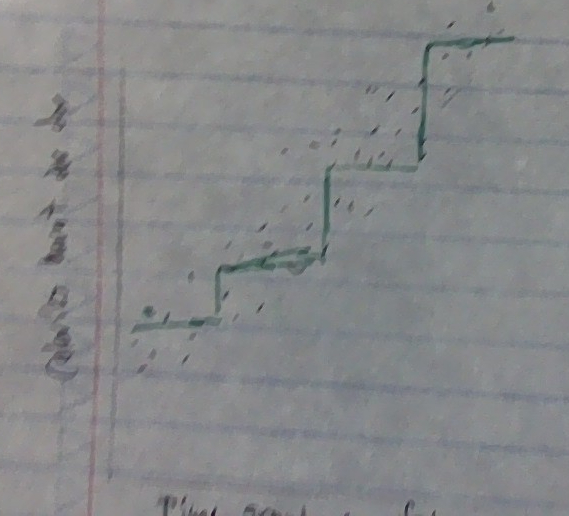

**Task2**:

What is a decision tree? How do they work?

*A decision tree says "if a value is within some range, it's this value", and it does that over the entire range of the data.*

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

*Depth can be seen as the number of 'steps' in the decision graph, but if you're looking at a standard visualization off a decision tree it's how 'tall' the tree gets. Usually, if a tree is too deep it's overfitting, and if it isn't deep enough it's overfitting. To figure out whether it's overfitting or under fitting, just look at it's graph!*

**Task4:**

How are BART models similar and different from a decision tree?

*A BART model expands on a decision tree, BART handles multiple variables and combines them into a single prediction. It also includes some optimizations ontop of a decision tree. Also, I think it automates the depth.*

**Task5**:

Why would we use a BART model instead of a decision tree?

*The automatic analysis of multiple data makes my life easier and it leaves room for interactions. Also, I don't have to worry about depth selection. It preforms as good as a decision tree but it automates and expands on many things in it.*

## Bartian Penguins

In [1]:
!pip install pymc-bart
import pymc_bart as pmb

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.0 MB/s eta 0:00:00


**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [2]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()

In [3]:
penguins.head()

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.75,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.80,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.25,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.45,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.65,male,2007


In [4]:
#Combine all my estimator variables into one dataframe
X = penguins[[
             'bill_length',
             'flipper_length',
             'bill_depth'
             ]]
#Define my estimand as Y
Y = penguins['body_mass']

In [5]:
with pm.Model() as model_pen:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_pen = pm.sample(compute_convergence_checks=False)

Output()

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

In [6]:
pm.sample_posterior_predictive(idata_pen,model_pen, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [9]:
posterior_mean = idata_pen.posterior["μ"]

μ_hdi = az.hdi(ary=idata_pen, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_pen, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


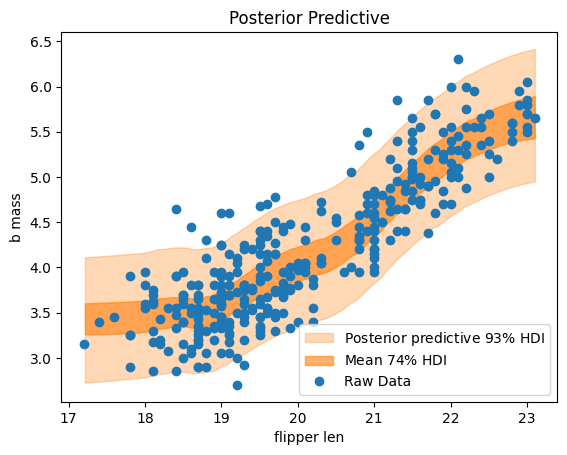

In [12]:
idx = np.argsort(X.to_numpy()[:, 1]) #grab input row (flip length = row 1)
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 1],#grab input row (flip length = row 1)
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 1],#grab input row (flip length = row 1)
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(penguins["flipper_length"], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper len",
    ylabel="b mass",
);

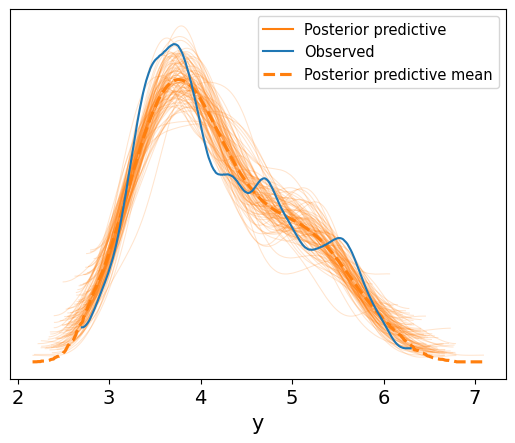

In [8]:
ax = az.plot_ppc(idata_pen, num_pp_samples=100, colors=["C1", "C0", "C1"])
#ax.set_xlim(0.0,0.0005)

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

*There appears to be a positive correlation between flipper length and body mass. Indicating that longer flippers require bigger bodies to support them. Another thing is that the most penguins have a mass of 3.5, and that it's a right skew.*

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='bill_length'>, <Axes: xlabel='flipper_length'>,
       <Axes: xlabel='bill_depth'>], dtype=object)

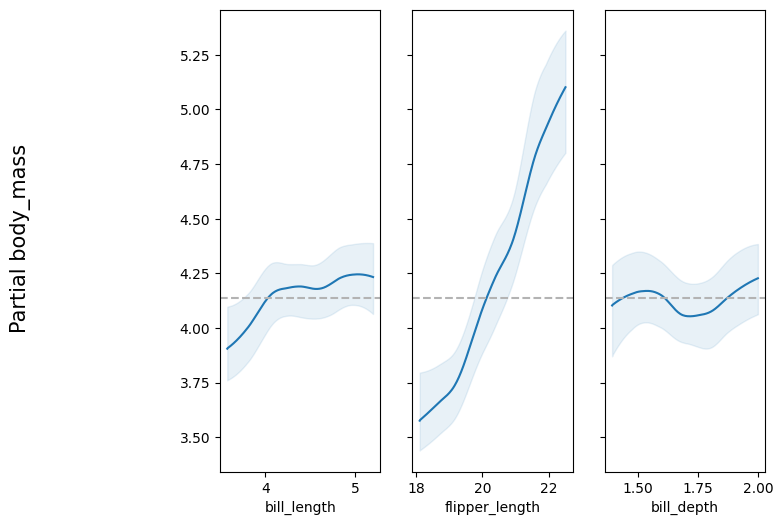

In [13]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='bill_length'>, <Axes: xlabel='flipper_length'>,
       <Axes: xlabel='bill_depth'>], dtype=object)

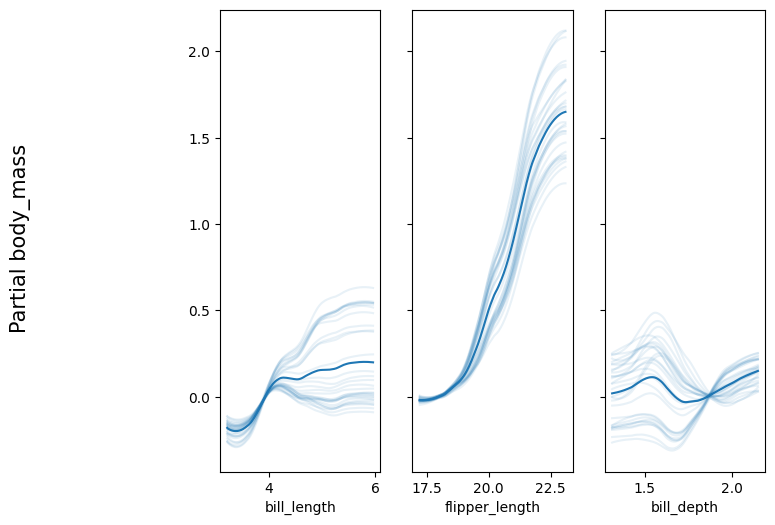

In [14]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

<Axes: ylabel='R²'>

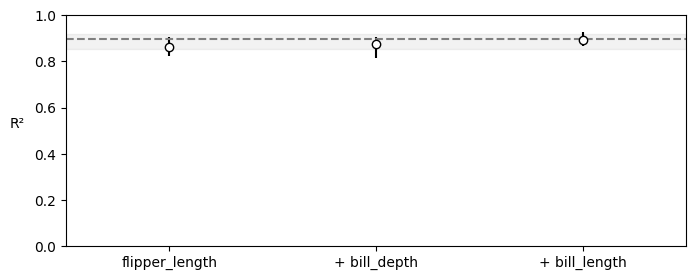

In [15]:
vi_counties = pmb.compute_variable_importance(idata_pen, μ_, X)
pmb.plot_variable_importance(vi_counties)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

*Flipper length is the most consistant, still conveying the positive correlation mentioned above, it probably doesn't need any interactions since it has a low variance. Bill length starts consistant, but it becomes more variant at later values, if I had to guess this complication means that  a interaction is necessary. Bill depth has lots of variance, with it only being consistant at a single point, it's likely caused by an interaction as well.*

##Adding Species to the Model

In [16]:
#Combine all my estimator variables into one dataframe
X = penguins[[
             'bill_length',
             'flipper_length',
             'bill_depth'
             ]]
#Define my estimand as Y
Y = penguins['body_mass']

In [18]:
#made by Gemini
X['species'] = pd.Categorical(penguins['species']).codes

/tmp/ipykernel_1792/552277468.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['species'] = pd.Categorical(penguins['species']).codes


In [19]:
with pm.Model() as model_pen:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_pen = pm.sample(compute_convergence_checks=False)

Output()

In [20]:
pm.sample_posterior_predictive(idata_pen,model_pen, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

In [21]:
posterior_mean = idata_pen.posterior["μ"]

μ_hdi = az.hdi(ary=idata_pen, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_pen, group="posterior_predictive", var_names=["y"]
).T

/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


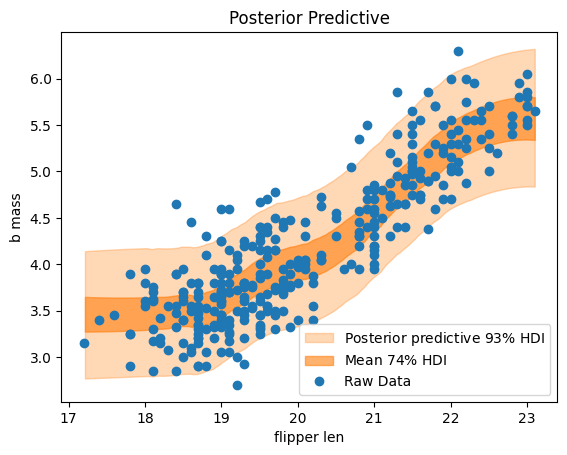

In [22]:
idx = np.argsort(X.to_numpy()[:, 1]) #grab input row (flip length = row 1)
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.to_numpy()[:, 1],#grab input row (flip length = row 1)
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": r"Posterior predictive $93\%$ HDI"},
)

az.plot_hdi(
    x=X.to_numpy()[:, 1],#grab input row (flip length = row 1)
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": r"Mean $74\%$ HDI"},
)
ax.plot(penguins["flipper_length"], penguins["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper len",
    ylabel="b mass",
);

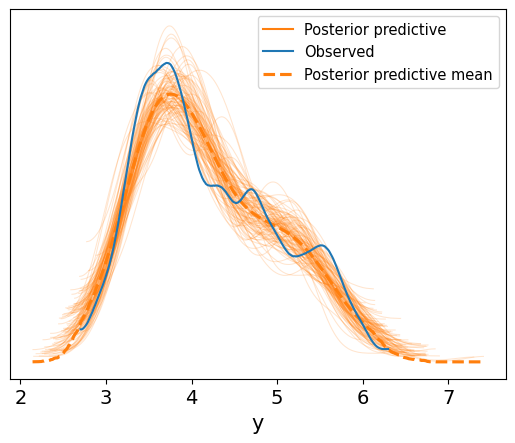

In [23]:
ax = az.plot_ppc(idata_pen, num_pp_samples=100, colors=["C1", "C0", "C1"])
#ax.set_xlim(0.0,0.0005)

array([<Axes: xlabel='bill_length'>, <Axes: xlabel='flipper_length'>,
       <Axes: xlabel='bill_depth'>, <Axes: xlabel='species'>],
      dtype=object)

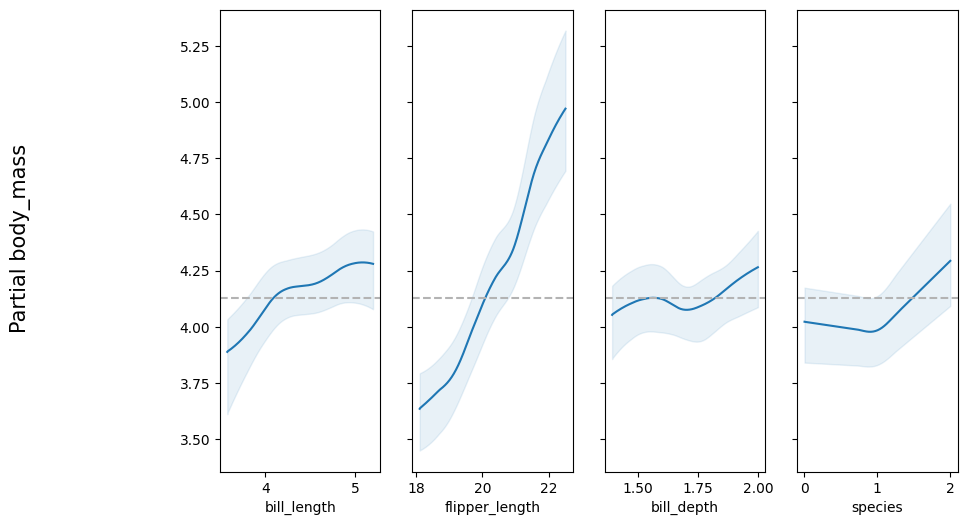

In [24]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

array([<Axes: xlabel='bill_length'>, <Axes: xlabel='flipper_length'>,
       <Axes: xlabel='bill_depth'>, <Axes: xlabel='species'>],
      dtype=object)

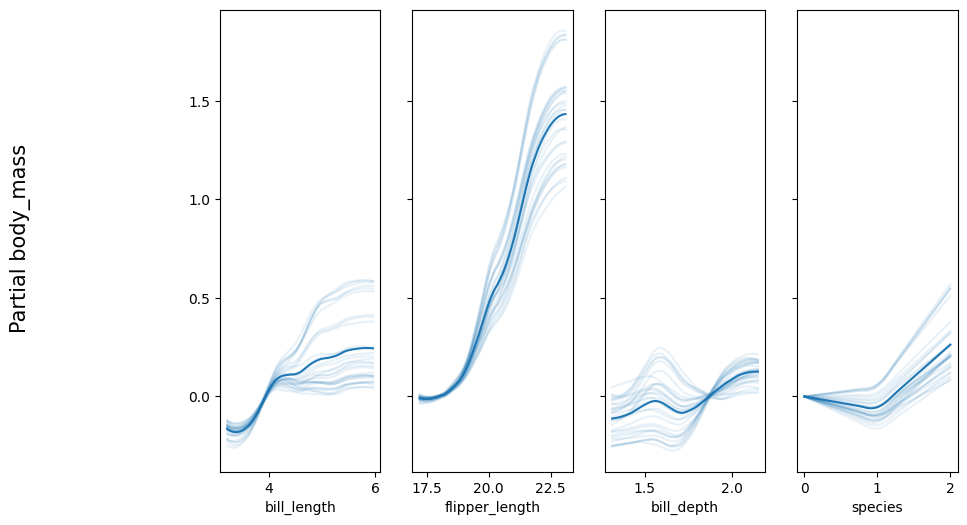

In [25]:
pmb.plot_ice( μ_, X, Y, grid=(1, 5), func=np.exp, figsize = (12,6))

<Axes: ylabel='R²'>

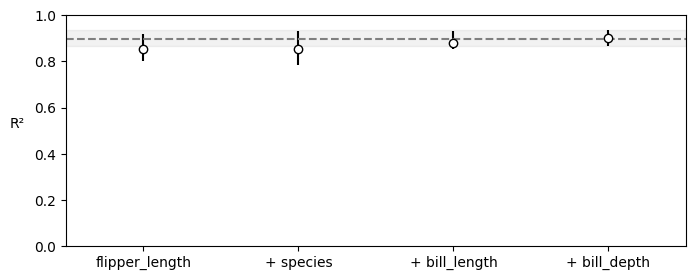

In [26]:
vi_counties = pmb.compute_variable_importance(idata_pen, μ_, X)
pmb.plot_variable_importance(vi_counties)